In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import f_regression
from sklearn.metrics import r2_score


In [3]:
df = pd.read_csv('house_price.csv');


In [5]:
df.head(50)

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
5,6,2012.667,7.1,2175.03000,3,24.96305,121.51254,32.1
6,7,2012.667,34.5,623.47310,7,24.97933,121.53642,40.3
7,8,2013.417,20.3,287.60250,6,24.98042,121.54228,46.7
8,9,2013.500,31.7,5512.03800,1,24.95095,121.48458,18.8
9,10,2013.417,17.9,1783.18000,3,24.96731,121.51486,22.1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [7]:
df.describe()


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [25]:
df.columns

Index(['X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

In [9]:
df.isnull().sum()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

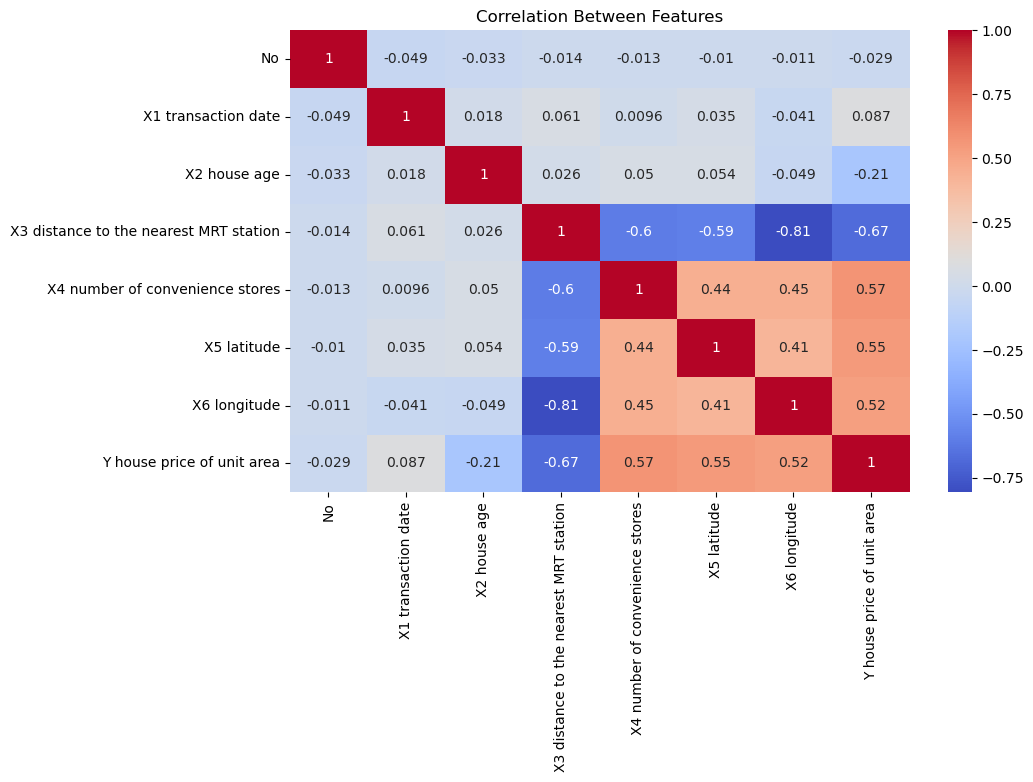

In [12]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Features")

plt.show()

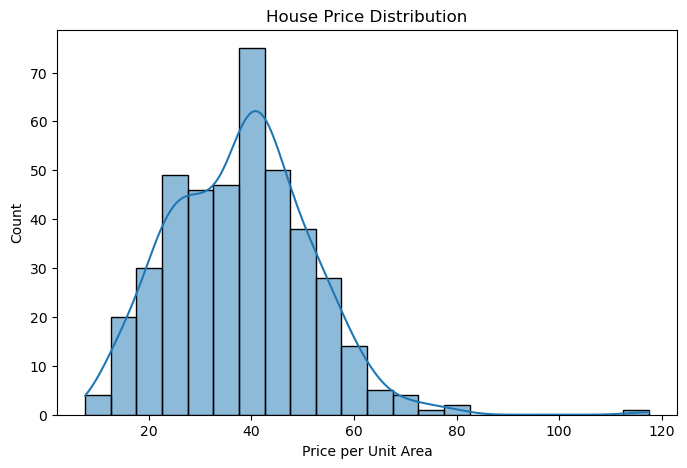

In [13]:
#House Price Distribution
#Understand price range

plt.figure(figsize=(8,5))

sns.histplot(
    df["Y house price of unit area"],
    kde=True
)

plt.title("House Price Distribution")

plt.xlabel("Price per Unit Area")

plt.show()

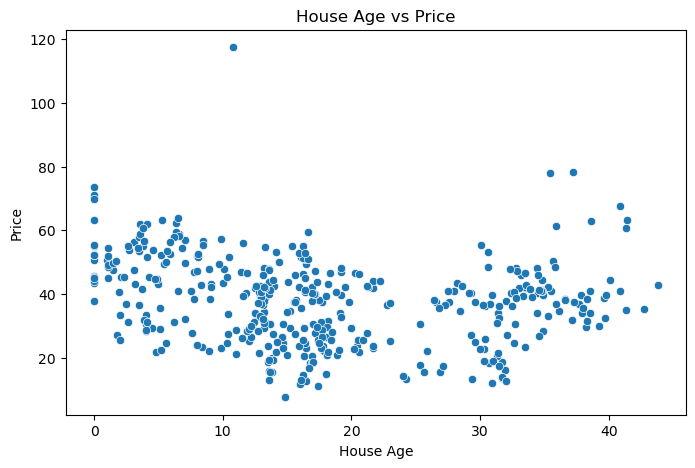

In [14]:
#House Age vs Price
#Does older house reduce price?

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["X2 house age"],
    y=df["Y house price of unit area"]
)

plt.title("House Age vs Price")

plt.xlabel("House Age")

plt.ylabel("Price")

plt.show()

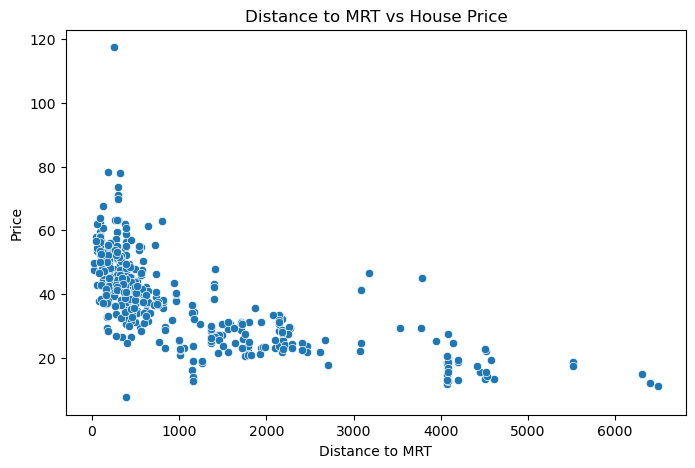

In [15]:
#Distance from MRT vs Price

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["X3 distance to the nearest MRT station"],
    y=df["Y house price of unit area"]
)

plt.title("Distance to MRT vs House Price")

plt.xlabel("Distance to MRT")

plt.ylabel("Price")

plt.show()

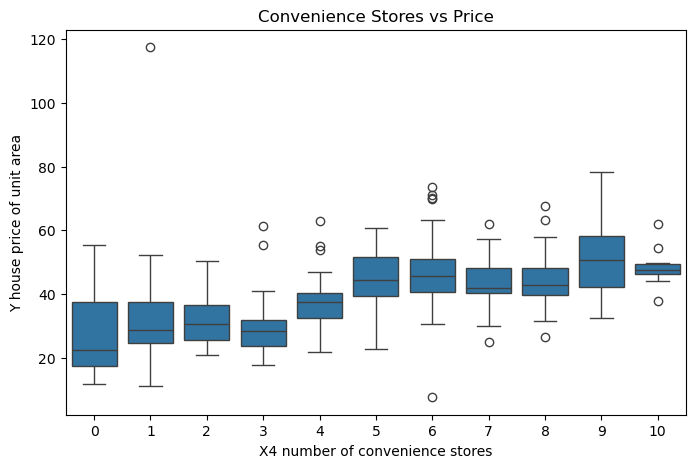

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["X4 number of convenience stores"],
    y=df["Y house price of unit area"]
)

plt.title("Convenience Stores vs Price")

plt.show()

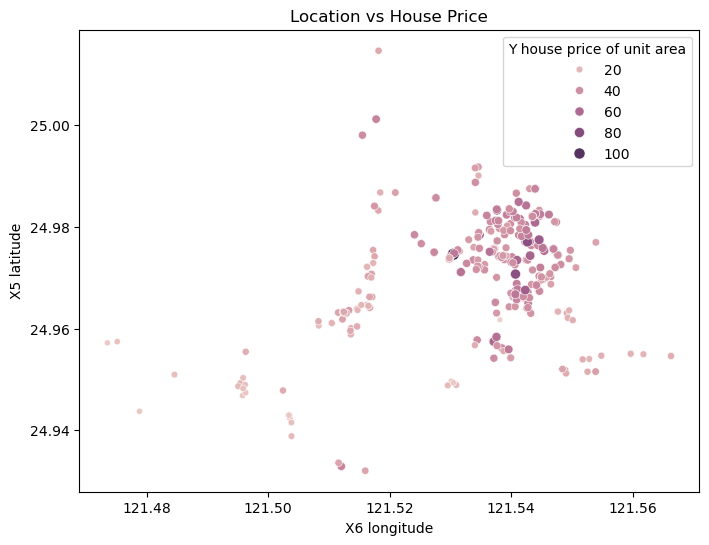

In [17]:
#latitude and longitude
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["X6 longitude"],
    y=df["X5 latitude"],
    size=df["Y house price of unit area"],
    hue=df["Y house price of unit area"]
)

plt.title("Location vs House Price")

plt.show()

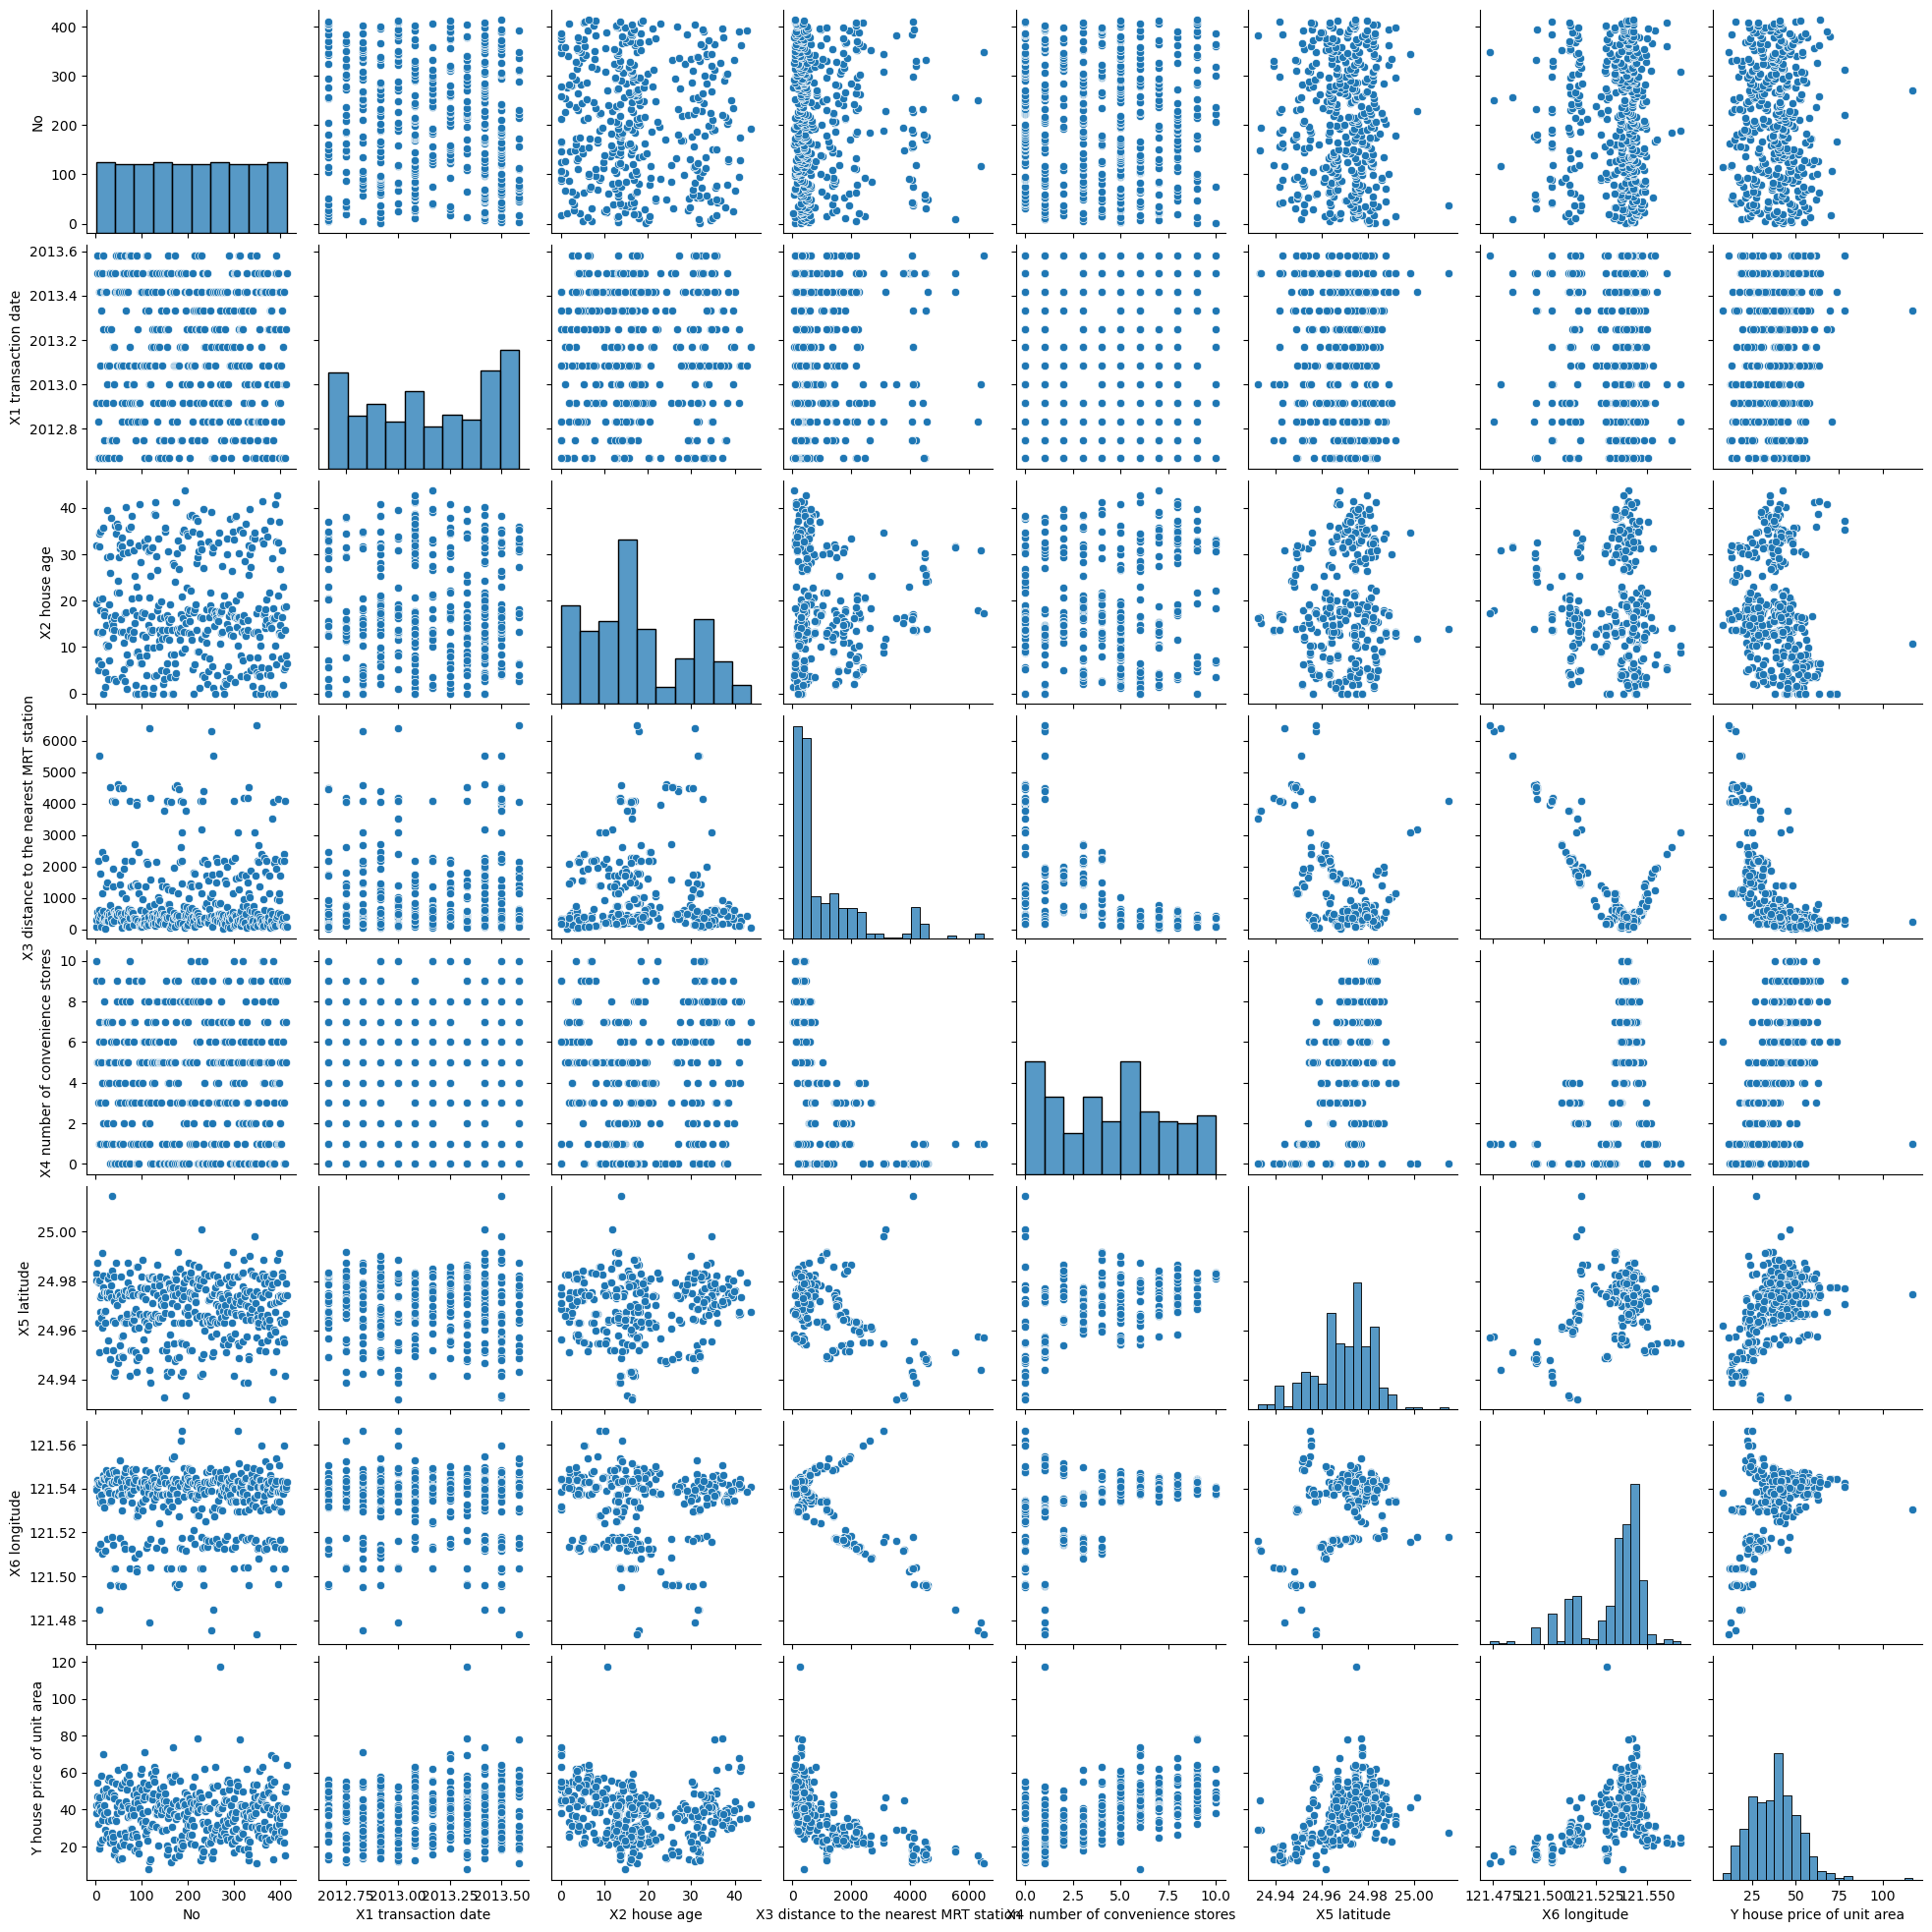

In [18]:
#Pairplot (All feature relationships)
sns.pairplot(df)

plt.show()

In [19]:
# filtering feature selection
df = df.drop("No", axis=1)

In [21]:
#f-test
X = df.drop("Y house price of unit area", axis=1)
y = df["Y house price of unit area"]

f_stat, p_values = f_regression(X, y)

for col, p in zip(X.columns, p_values):
    print(col, "p-value:", p)

X1 transaction date p-value: 0.07537113398881116
X2 house age p-value: 1.560425504797083e-05
X3 distance to the nearest MRT station p-value: 4.639825030362316e-56
X4 number of convenience stores p-value: 3.4134833404959702e-37
X5 latitude p-value: 1.3877612965769521e-33
X6 longitude p-value: 1.7651887324465206e-30


In [22]:
X = df.drop(["Y house price of unit area", "X1 transaction date"], axis=1)
y = df["Y house price of unit area"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [26]:


print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.6746481382828227
